# Drug Response Classification using Support Vector Machine (SVM)
## Machine Learning Assignment Notebook

This notebook demonstrates how Support Vector Machines (SVM) can be used to classify patient drug responses.

Tasks Covered:
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Data Visualization
- SVM Implementation
- Model Evaluation
- Hyperparameter Tuning
- Kernel Comparison


## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Upload and Load Dataset

In [3]:
df = pd.read_csv('Pharma_Industry.csv')
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


## Task 1: Exploratory Data Analysis (EDA)

In [4]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


(500, 6)

### Check Missing Values

In [5]:
df.isnull().sum()

,0
Drug Dosage (mg),0
Systolic Blood Pressure (mmHg),0
Heart Rate (BPM),0
Liver Toxicity Index (U/L),0
Blood Glucose Level (mg/dL),0
Drug Response,0


### Feature Distribution (Histograms)

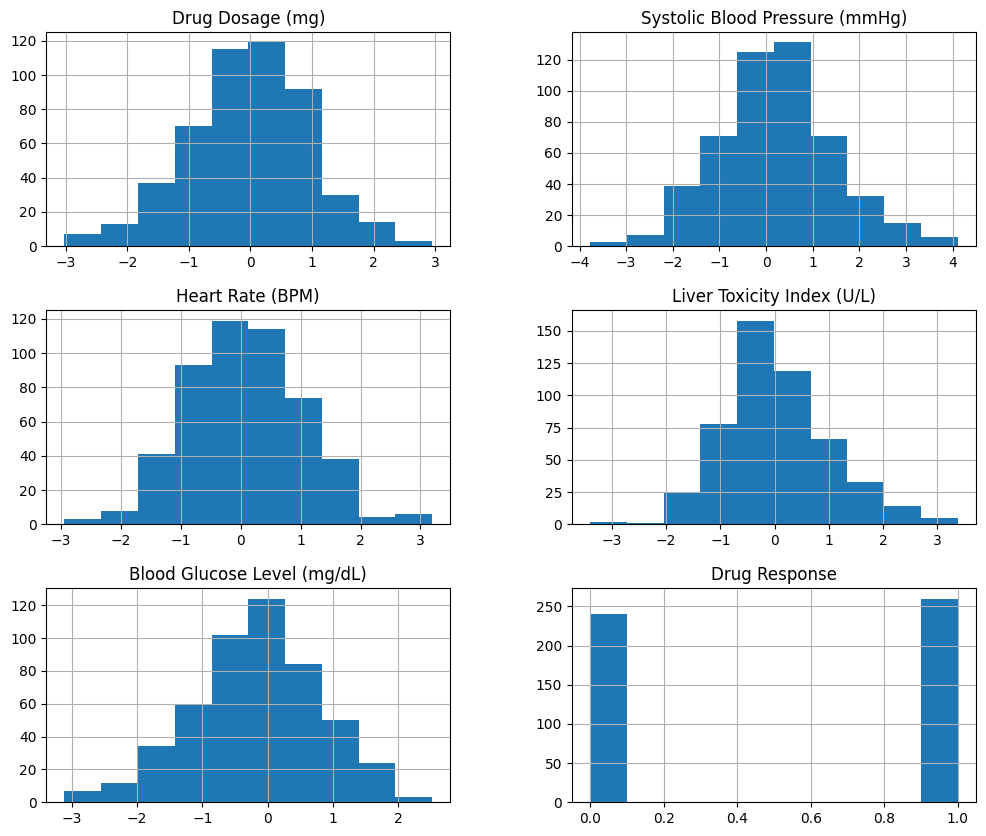

In [6]:
df.hist(figsize=(12,10))
plt.show()

### Boxplots

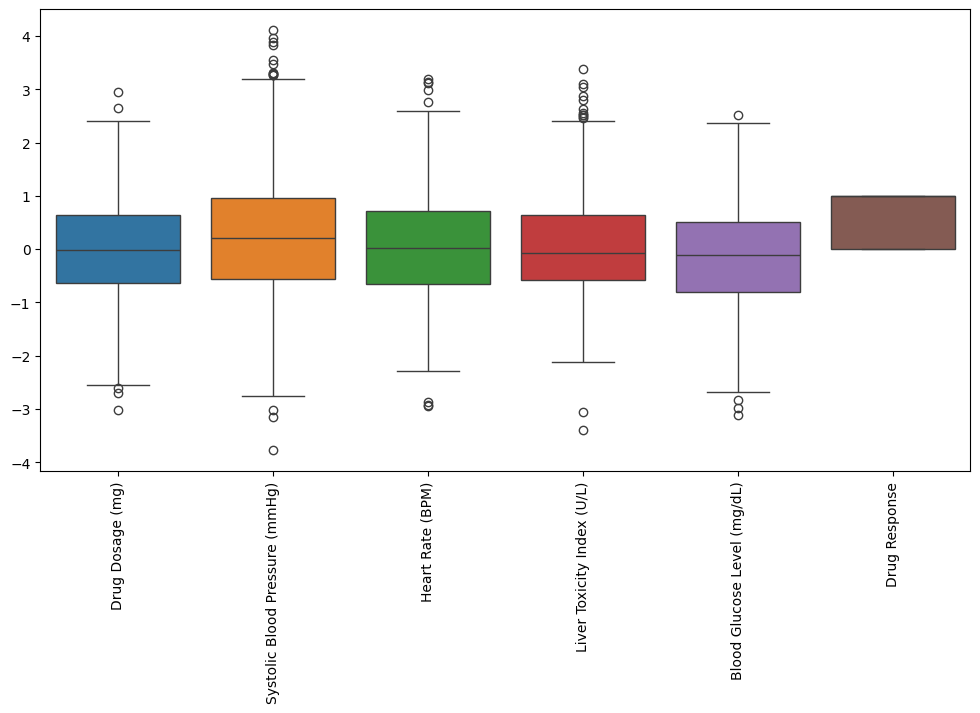

In [7]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

### Correlation Heatmap

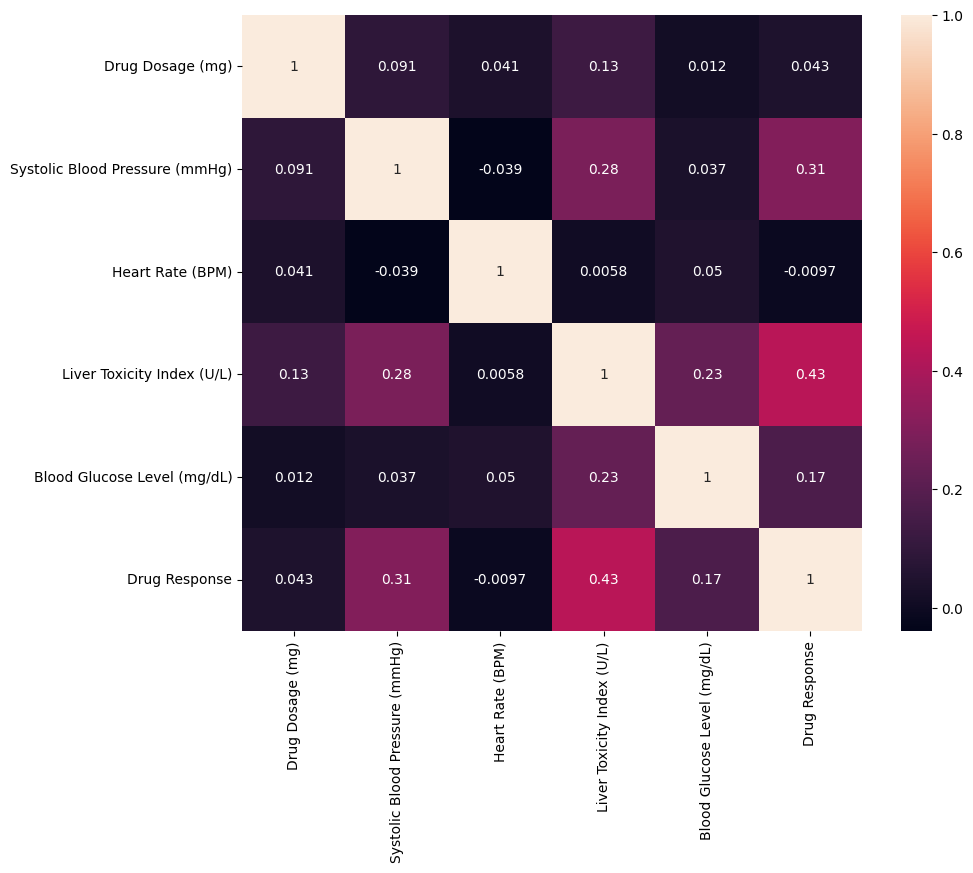

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

## Task 2: Data Preprocessing

In [9]:
# Encode categorical columns if present
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

### Split Dataset

In [11]:
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Feature Scaling

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Task 3: Data Visualization

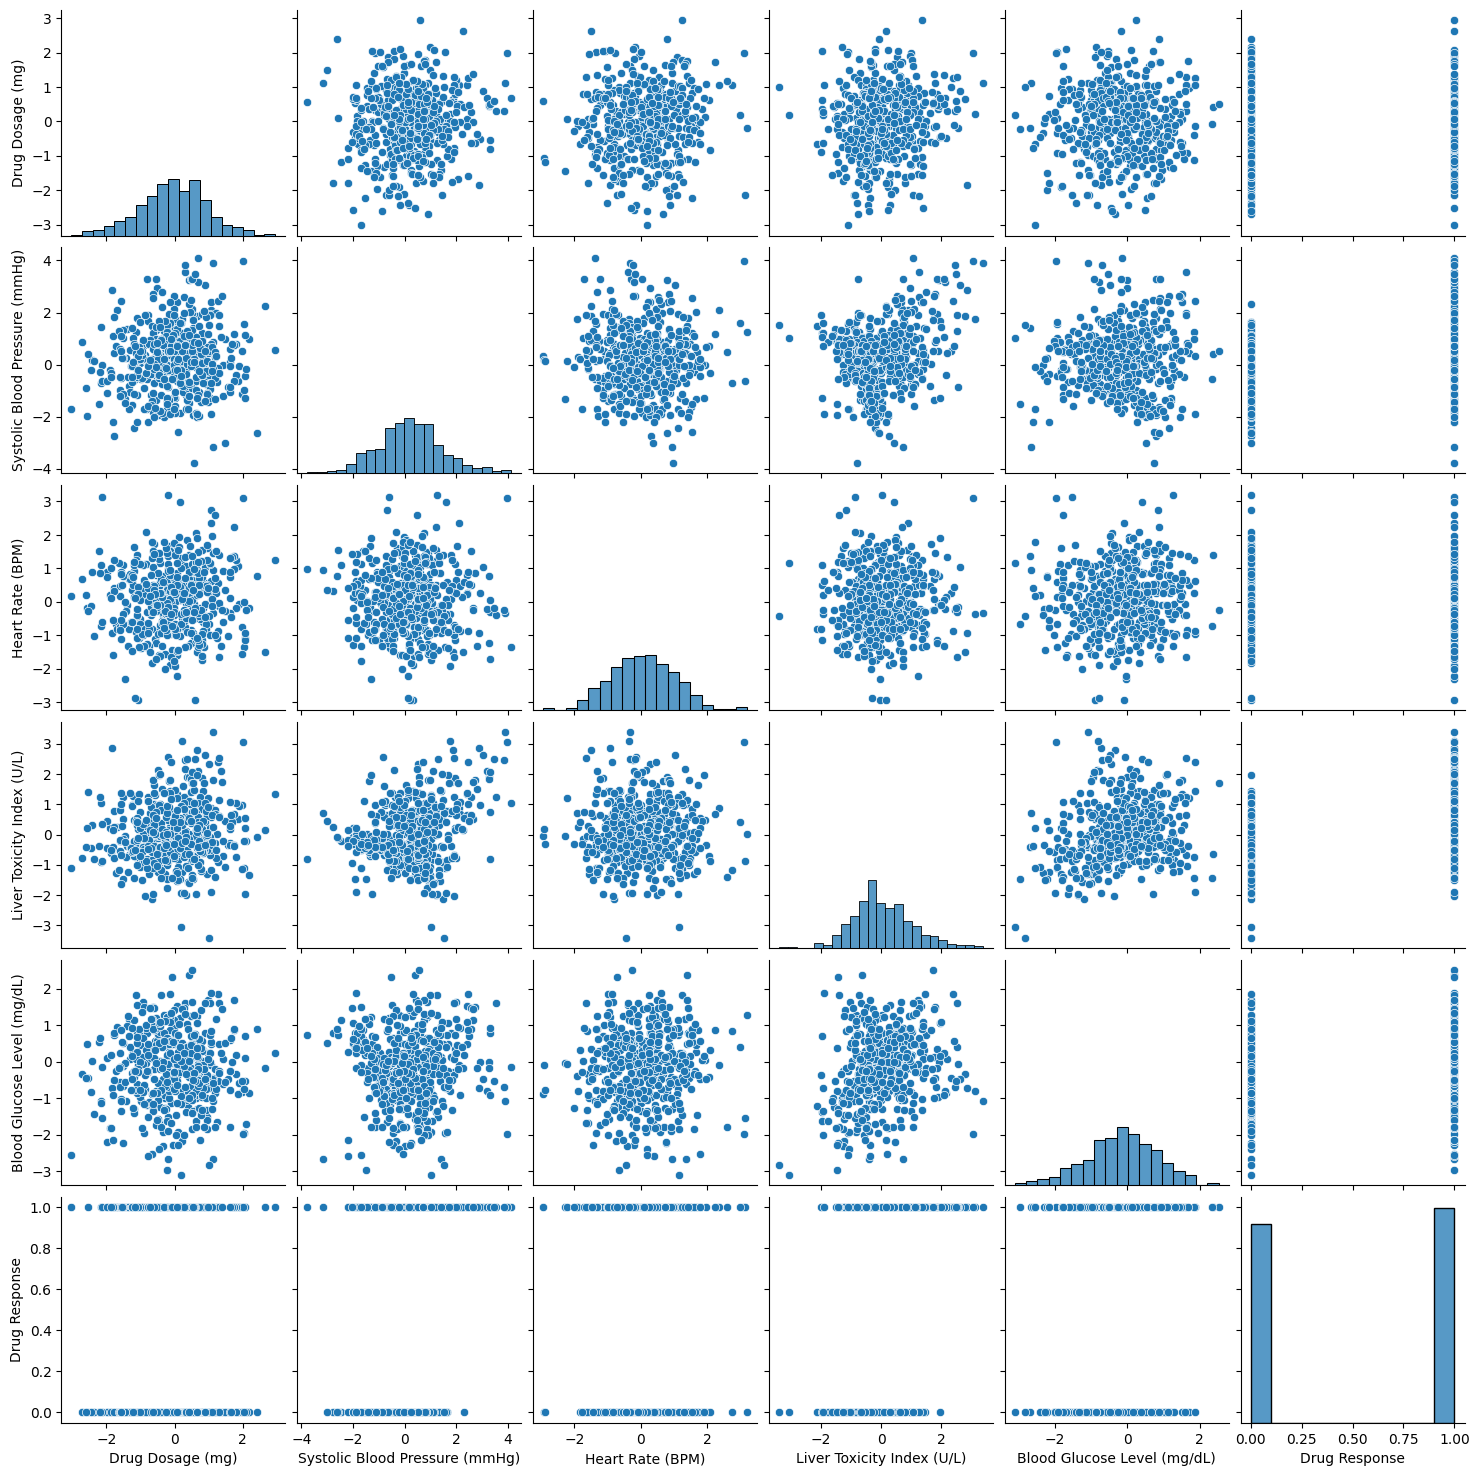

In [13]:
sns.pairplot(df)
plt.show()

### Class Distribution

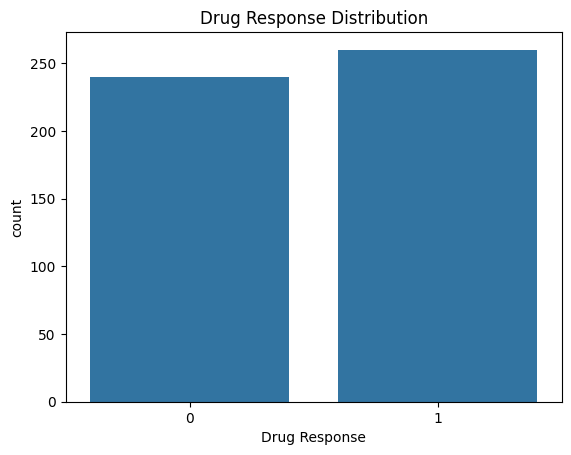

In [14]:
sns.countplot(x=y)
plt.title('Drug Response Distribution')
plt.show()

## Task 4: SVM Implementation

In [15]:
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

SVC(kernel='linear')

### Model Prediction

In [16]:
y_pred = svm_model.predict(X_test)

### Model Evaluation

In [17]:
print('Accuracy:', accuracy_score(y_test, y_pred))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:\n')
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.78

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.82      0.77        44
           1       0.84      0.75      0.79        56

    accuracy                           0.78       100
   macro avg       0.78      0.78      0.78       100
weighted avg       0.79      0.78      0.78       100


Confusion Matrix:

[[36  8]
 [14 42]]


## Task 5: Visualization of Results

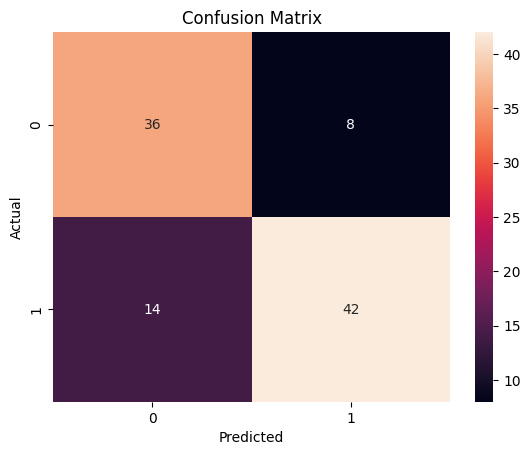

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Task 6: Hyperparameter Tuning

In [19]:
params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf','poly'],
}

grid = GridSearchCV(SVC(), params, cv=3)
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)

Best Parameters: {'C': 1, 'kernel': 'rbf'}


## Task 7: Kernel Comparison

In [20]:
kernels = ['linear','poly','rbf']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(k, 'Accuracy:', acc)

linear Accuracy: 0.78
poly Accuracy: 0.71
rbf Accuracy: 0.84


## Analysis

SVM is effective for high‑dimensional classification problems.

Strengths:
- Works well with complex boundaries
- Effective in high dimensional datasets
- Robust against overfitting when properly tuned

Weaknesses:
- Computationally expensive for very large datasets
- Requires careful parameter tuning

In pharmaceutical datasets, SVM helps classify drug responses accurately, supporting personalized medicine.